Research Question 8: How do the number and average timing of substitutions affect the number of shots on goal in the second half?

Retrieving the Data:

In [3]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from scipy import stats
import json
import numpy as np

import soccerdata as sd 

data = sd.WhoScored(leagues="GER-Bundesliga", seasons="2024/2025", headless=True)

# Creating a list of all the game IDs of the Bundesliga season 2024/2025
game_ids = data.read_schedule()["game_id"].to_list()

events = data.read_events(match_id=game_ids)

substitutions = events[events["type"]=="SubstitutionOff"]
substitutions["minutes_played"] = (90 - substitutions["minute"]).clip(lower=0)

shot_types = ["Goal", "MissedShots", "SavedShot", "ShotOnPost"]
shots = events[(events["type"].isin(shot_types)) & (events["period"] == "SecondHalf")]

# Aggregate all the shots per match and team

shot_count = shots.groupby(["game_id", "team_id"]).size().reset_index(name="total_shots_secondHalf")

sub_count = substitutions.groupby(["game_id", "team_id"]).agg(
    sub_count=("type", "count"),
    avg_sub=("minute", "mean")
).reset_index()

total_sub_time = substitutions.groupby(["game_id", "team_id"])["minutes_played"].sum().reset_index(name="total_sub_time")

df_RQ8 = pd.merge(sub_count, shot_count, on=["game_id", "team_id"], how="left").fillna(0)

df_RQ8 = pd.merge(df_RQ8, total_sub_time, on=["game_id", "team_id"], how="left").fillna(0)

df_RQ8.to_json("RQ8.json", orient="records", indent=4)
df_RQ8.to_csv("RQ8.csv", index=False)




[03/11/26 21:37:14] INFO     Saving cached data to C:\Users\hinri\soccerdata\data\WhoScored          ]8;id=927387;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=243430;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py#249\249]8;;\

[03/11/26 21:37:17] INFO     Retrieving calendar for GER-Bundesliga 2425                           ]8;id=213167;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=497441;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#365\365]8;;\

                    INFO     [1/10] Retrieving fixtures for GER-Bundesliga 2425                    ]8;id=137109;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=92850;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#396\396]8;;\

                    INFO     [2/10] Retrieving fixtures for GER-Bundesliga 2425                    ]8;id=102979;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=214506;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#396\396]8;;\

                    INFO     [3/10] Retrieving fixtures for GER-Bundesliga 2425                    ]8;id=844286;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=895200;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#396\396]8;;\

...

[03/11/26 21:37:39] INFO     [303/306] Retrieving game with id=1834451                             ]8;id=799153;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=750851;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [304/306] Retrieving game with id=1834459                             ]8;id=469303;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=684826;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [305/306] Retrieving game with id=1834447                             ]8;id=482171;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=386820;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [306/306] Retrieving game with id=1834463                             ]8;id=784634;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=70033;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

[03/11/26 21:37:49] WARNING  C:\Users\hinri\AppData\Local\Temp\ipykernel_16072\2790203522.py:18:    warnings.py:110
                             SettingWithCopyWarning:                                                               
                             A value is trying to be set on a copy of a slice from a DataFrame.                    
                             Try using .loc = value instead                                                        
                                                                                                                   
                             See the caveats in the documentation:                                                 
                             https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#                
                             returning-a-view-versus-a-copy                                                        
                               substitutions["minutes_played"] = (90 -                                             
                             substitutions["minute"]).clip(lower=0)                                                
                                                                                                                   

Creating the visualization:

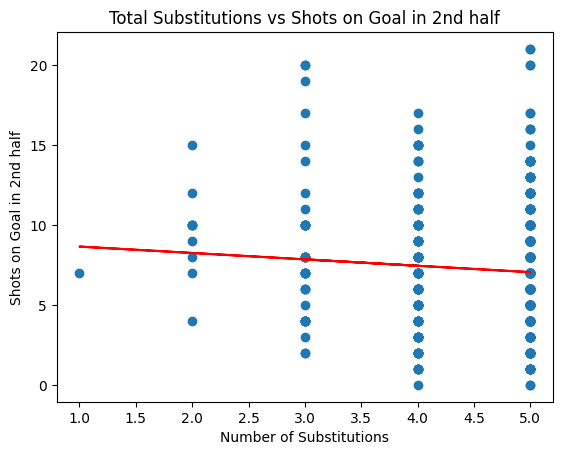

In [11]:
Y = df_RQ8["total_shots_secondHalf"]
X_subs = df_RQ8["sub_count"]

m, b = np.polyfit(X_subs, Y, 1)

plt.figure()
plt.scatter(X_subs, Y, alpha=1)
plt.plot(X_subs, m*X_subs + b, color="red")
plt.title("Total Substitutions vs Shots on Goal in 2nd half")
plt.xlabel("Number of Substitutions")
plt.ylabel("Shots on Goal in 2nd half")
plt.show()

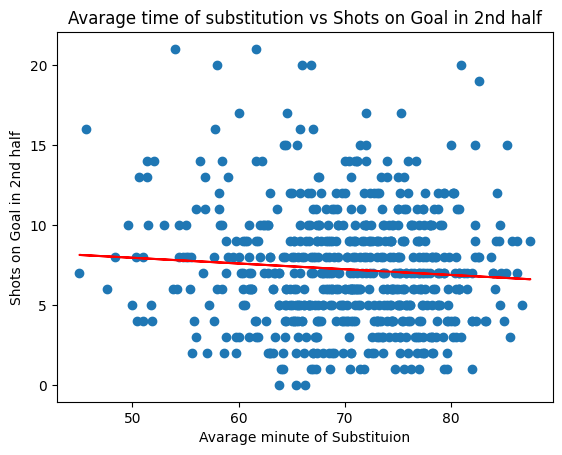

In [12]:
X_avg = df_RQ8["avg_sub"]

m, b = np.polyfit(X_avg, Y, 1)

plt.figure()
plt.scatter(X_avg, Y, alpha=1)
plt.plot(X_avg, m*X_avg + b, color="red")
plt.title("Avarage time of substitution vs Shots on Goal in 2nd half")
plt.xlabel("Avarage minute of Substituion")
plt.ylabel("Shots on Goal in 2nd half")
plt.show()

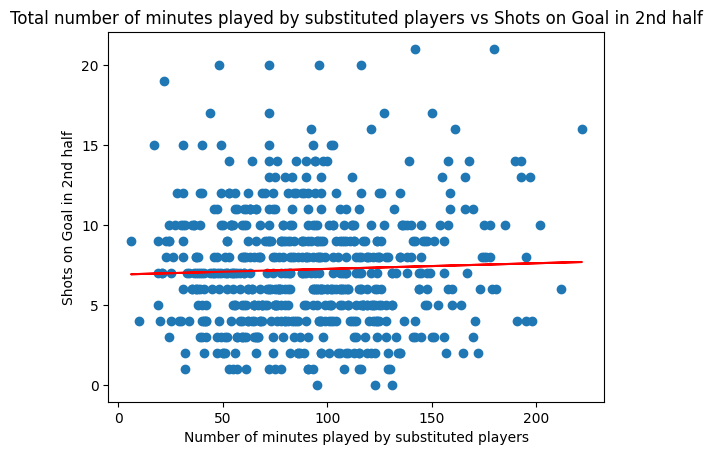

In [10]:
X_sum = df_RQ8["total_sub_time"]

m, b = np.polyfit(X_sum, Y, 1)

plt.figure()
plt.scatter(X_sum, Y, alpha=1)
plt.plot(X_sum, m*X_sum + b, color="red")
plt.title("Total number of minutes played by substituted players vs Shots on Goal in 2nd half")
plt.xlabel("Number of minutes played by substituted players")
plt.ylabel("Shots on Goal in 2nd half")
plt.show()
